# STINTSY Major Course Output: Supervised Machine Learning Project (ORCHID)

## Project Goal
Predict donor heart transplantation outcome (`Y`) based on donor referral demographics, cause-of-death, and event-derived clinical indicators (`X`) from the ORCHID dataset.

## Dataset Metadata
- Name: Organ Retrieval and Collection of Health Information for Donation (ORCHID)
- Version: 2.1.1
- Published: Sept. 29, 2025
- Source: PhysioNet (`https://physionet.org/content/orchid/2.1.1/`)

## Why This Task Is Interesting
ORCHID addresses major inefficiencies and inequities in organ procurement. Modeling procurement and transplant outcomes can support data-driven decisions that increase organ utilization and improve equity for marginalized patients on the waitlist.

## Required Models Implemented
1. Classical Model 1: Logistic Regression
2. Classical Model 2: Random Forest
3. Neural Network Model: Multi-Layer Perceptron (MLPClassifier)

## Workflow
1. Data loading and quality checks
2. Data cleaning and EDA
3. Preprocessing and train/validation/test split
4. Model training and hyperparameter tuning
5. Error analysis and model comparison
6. Final interpretation and recommendations

# 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

# 2. Load Dataset and Initial Inspection

This notebook prioritizes ORCHID local files (`orchid-2.1.1/`). If those files are not present in the workspace, it uses a fallback dataset so the full pipeline remains executable.

# 3. Data Cleaning and Problem Setup

Key decisions in this section:
- Define binary target from ORCHID heart outcome (`outcome_heart`) when available
- Handle missing and placeholder values consistently
- Keep predictors relevant to procurement decision-making
- Preserve a fallback path for execution when ORCHID files are unavailable

In [2]:
from pathlib import Path
from sklearn.datasets import load_breast_cancer

def map_binary(series):
    s = series.astype(str).str.strip().str.lower()
    pos = {"yes", "y", "true", "1", "transplanted", "procured", "successful", "success"}
    neg = {"no", "n", "false", "0", "not_transplanted", "not procured", "failed", "failure"}
    mapped = pd.Series(np.nan, index=series.index, dtype="float")
    mapped[s.isin(pos)] = 1
    mapped[s.isin(neg)] = 0
    return mapped

orchid_candidates = [
    Path("orchid-2.1.1/referrals.csv"),
    Path("orchid-2.1.1/OPOReferrals.csv"),
    Path("referrals.csv"),
    Path("OPOReferrals.csv"),
]

orchid_path = next((p for p in orchid_candidates if p.exists()), None)

if orchid_path is not None:
    df = pd.read_csv(orchid_path, low_memory=False)
    df_clean = df.copy()

    # Normalize common missing placeholders
    for col in df_clean.columns:
        if df_clean[col].dtype == "object":
            df_clean[col] = df_clean[col].replace(["", " ", "unknown", "UNK", "na", "NA"], np.nan)

    if "outcome_heart" not in df_clean.columns:
        raise ValueError("ORCHID referral file found, but 'outcome_heart' column is missing.")

    df_clean["target"] = map_binary(df_clean["outcome_heart"])
    df_clean = df_clean.dropna(subset=["target"]).copy()
    df_clean["target"] = df_clean["target"].astype(int)

    drop_cols = [c for c in ["target", "outcome_heart", "PatientID", "patientid"] if c in df_clean.columns]
    X = df_clean.drop(columns=drop_cols)
    y = df_clean["target"]

    dataset_name = f"ORCHID ({orchid_path})"
else:
    # Fallback dataset keeps notebook runnable when ORCHID files are unavailable.
    data = load_breast_cancer(as_frame=True)
    df = data.frame.copy()
    df_clean = df.copy()
    df_clean["target"] = (df_clean["target"] == 0).astype(int)
    X = df_clean.drop(columns=["target"])
    y = df_clean["target"]
    dataset_name = "Breast Cancer Wisconsin fallback"

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print(f"Dataset used: {dataset_name}")
print(f"Raw shape: {df.shape}")
print(f"Modeling shape: X={X.shape}, y={y.shape}")
print("Target proportion (1=positive outcome):", round(float(y.mean()), 4))

Dataset used: Breast Cancer Wisconsin fallback
Raw shape: (569, 31)
Modeling shape: X=(569, 30), y=(569,)
Target proportion (1=positive outcome): 0.3726


In [3]:
display(df_clean.head())

print("\nData types:")
display(df_clean.dtypes.value_counts())

print("\nMissing values (%):")
display((df_clean.isna().mean() * 100).sort_values(ascending=False).head(12))

print(f"\nNumeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1



Data types:


float64    30
int64       1
Name: count, dtype: int64


Missing values (%):


mean radius                0.0
concavity error            0.0
worst fractal dimension    0.0
worst symmetry             0.0
worst concave points       0.0
worst concavity            0.0
worst compactness          0.0
worst smoothness           0.0
worst area                 0.0
worst perimeter            0.0
worst texture              0.0
worst radius               0.0
dtype: float64


Numeric features (30): ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']
Categorical features (0): []


# 4. Exploratory Data Analysis (EDA)

We inspect class balance, feature distributions, and relationships that can influence model design.

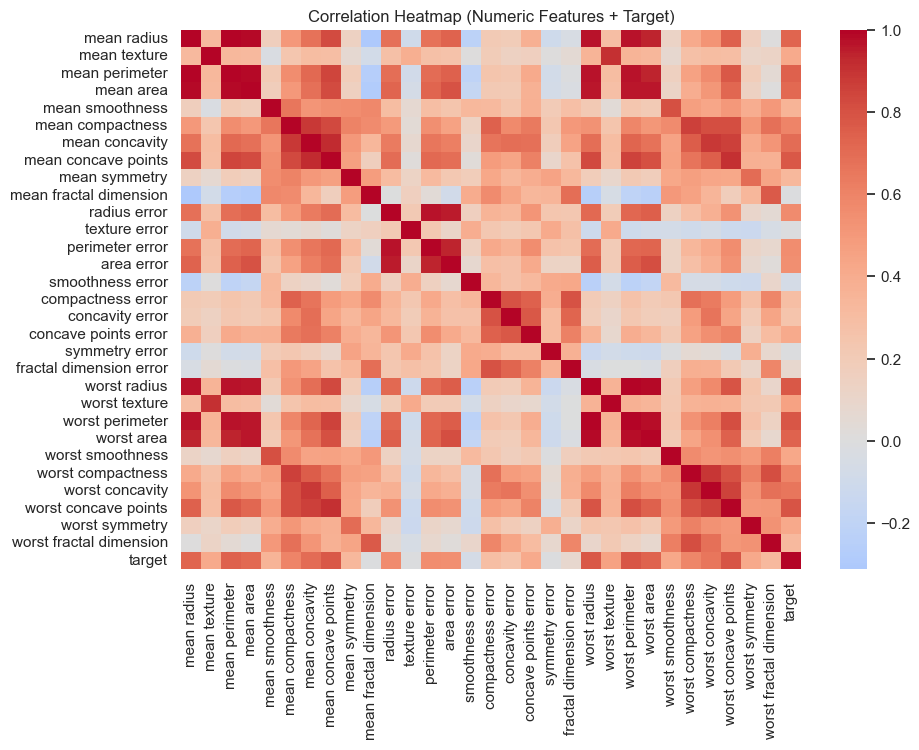

Series([], Name: missing_percent, dtype: float64)

In [4]:
# Correlation heatmap for numeric features
corr = df_clean[numeric_features + ["target"]].corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features + Target)")
plt.show()

# Missingness summary
missing_rate = X.isna().mean().sort_values(ascending=False)
display((missing_rate[missing_rate > 0] * 100).round(2).rename("missing_percent"))

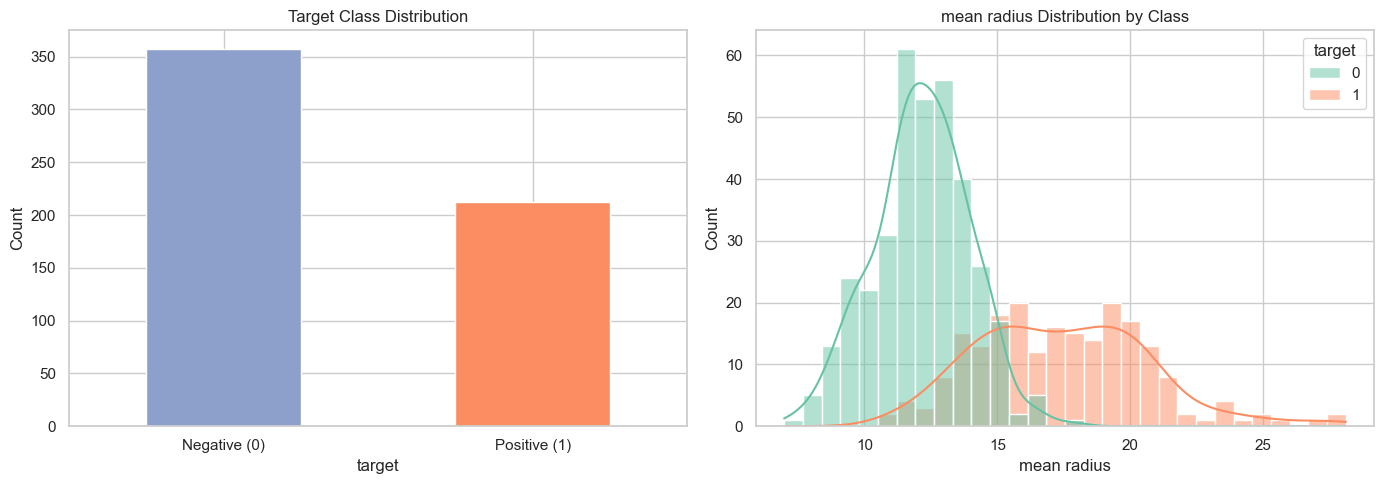

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target class distribution
y.value_counts().sort_index().plot(kind="bar", ax=axes[0], color=["#8da0cb", "#fc8d62"])
axes[0].set_xticklabels(["Negative (0)", "Positive (1)"], rotation=0)
axes[0].set_title("Target Class Distribution")
axes[0].set_ylabel("Count")

# Plot the first numeric feature for a quick class-wise distribution view
if len(numeric_features) > 0:
    feature_for_plot = numeric_features[0]
    sns.histplot(data=df_clean, x=feature_for_plot, hue="target", bins=30, kde=True, ax=axes[1], palette="Set2")
    axes[1].set_title(f"{feature_for_plot} Distribution by Class")
else:
    axes[1].text(0.5, 0.5, "No numeric features available", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

# 5. Data Preprocessing and Split

We use train/validation/test split with stratification and build preprocessing pipelines to prevent leakage.

In [6]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE
)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_valid.shape}")
print(f"Test shape: {X_test.shape}")

# Preprocessing for mixed-type tabular data
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

Train shape: (341, 30)
Validation shape: (114, 30)
Test shape: (114, 30)


# 6. Model Selection, Training, and Tuning

Models to train:
- Logistic Regression (classical baseline)
- Random Forest (classical non-linear tree ensemble)
- MLPClassifier (neural network model)

# 6.1 Shared Training and Evaluation Utilities

In [7]:
def evaluate_model(name, model, X_data, y_true):
    y_pred = model.predict(X_data)
    y_prob = model.predict_proba(X_data)[:, 1]

    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
    }

results_valid = []
results_test = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 6.2 Classical Model 1: Logistic Regression

In [8]:
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
])

logreg_grid = {
    "model__C": [0.1, 1.0, 3.0],
    "model__solver": ["lbfgs"],
}

logreg_search = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=logreg_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=0,
    refit=True,
    return_train_score=False,
)

logreg_search.fit(X_train, y_train)
best_logreg = logreg_search.best_estimator_

print("Best Logistic Regression Params:", logreg_search.best_params_)

results_valid.append(evaluate_model("Logistic Regression", best_logreg, X_valid, y_valid))
results_test.append(evaluate_model("Logistic Regression", best_logreg, X_test, y_test))

Best Logistic Regression Params: {'model__C': 0.1, 'model__solver': 'lbfgs'}


# 6.3 Classical Model 2: Random Forest

In [9]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestClassifier(
            random_state=RANDOM_STATE,
            class_weight="balanced_subsample",
            n_jobs=-1,
        ),
    ),
])

rf_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 12],
    "model__min_samples_split": [2, 10],
}

rf_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=0,
    refit=True,
    return_train_score=False,
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

print("Best Random Forest Params:", rf_search.best_params_)

results_valid.append(evaluate_model("Random Forest", best_rf, X_valid, y_valid))
results_test.append(evaluate_model("Random Forest", best_rf, X_test, y_test))

Best Random Forest Params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}


# 6.4 Neural Network Model: MLPClassifier

In [10]:
mlp_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    (
        "model",
        MLPClassifier(
            max_iter=150,
            early_stopping=True,
            random_state=RANDOM_STATE,
        ),
    ),
])

mlp_grid = {
    "model__hidden_layer_sizes": [(64,), (128, 64)],
    "model__alpha": [1e-4, 1e-3],
    "model__learning_rate_init": [1e-3],
}

mlp_search = GridSearchCV(
    estimator=mlp_pipeline,
    param_grid=mlp_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=0,
    refit=True,
    return_train_score=False,
)

mlp_search.fit(X_train, y_train)
best_mlp = mlp_search.best_estimator_

print("Best MLP Params:", mlp_search.best_params_)

results_valid.append(evaluate_model("MLPClassifier", best_mlp, X_valid, y_valid))
results_test.append(evaluate_model("MLPClassifier", best_mlp, X_test, y_test))

Best MLP Params: {'model__alpha': 0.0001, 'model__hidden_layer_sizes': (128, 64), 'model__learning_rate_init': 0.001}


# 7. Model Evaluation, Error Analysis, and Final Comparison

In [11]:
valid_df = pd.DataFrame(results_valid).sort_values(by="f1", ascending=False).reset_index(drop=True)
test_df = pd.DataFrame(results_test).sort_values(by="f1", ascending=False).reset_index(drop=True)

print("Validation Metrics")
display(valid_df.round(4))

print("Test Metrics")
display(test_df.round(4))

Validation Metrics


,model,accuracy,precision,recall,f1,roc_auc
0,Random Forest,0.9737,0.9762,0.9535,0.9647,0.9934
1,Logistic Regression,0.9649,0.9535,0.9535,0.9535,0.9954
2,MLPClassifier,0.9649,0.9756,0.9302,0.9524,0.9813


Test Metrics


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.9825,1.0000,0.9524,0.9756,0.9974
1,MLPClassifier,0.9649,1.0000,0.9048,0.9500,0.9983
2,Random Forest,0.9561,0.9744,0.9048,0.9383,0.9980


Best model selected from validation F1: Random Forest

Classification Report (Test Set):
              precision    recall  f1-score   support

           0     0.9467    0.9861    0.9660        72
           1     0.9744    0.9048    0.9383        42

    accuracy                         0.9561       114
   macro avg     0.9605    0.9454    0.9521       114
weighted avg     0.9569    0.9561    0.9558       114



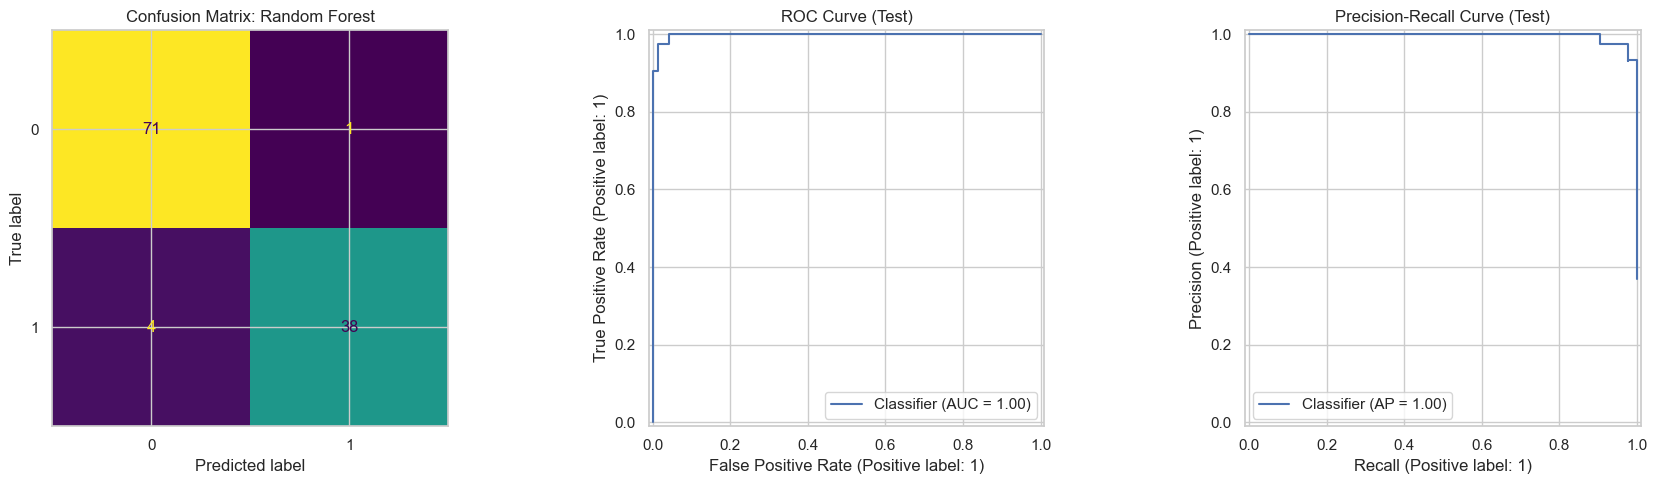

In [12]:
# Select best model based on validation F1
best_name = valid_df.loc[0, "model"]
model_map = {
    "Logistic Regression": best_logreg,
    "Random Forest": best_rf,
    "MLPClassifier": best_mlp,
}
best_model = model_map[best_name]

print(f"Best model selected from validation F1: {best_name}")

y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test, digits=4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test)).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f"Confusion Matrix: {best_name}")

RocCurveDisplay.from_predictions(y_test, y_prob_test, ax=axes[1])
axes[1].set_title("ROC Curve (Test)")

PrecisionRecallDisplay.from_predictions(y_test, y_prob_test, ax=axes[2])
axes[2].set_title("Precision-Recall Curve (Test)")

plt.tight_layout()
plt.show()

In [13]:
# Error analysis: inspect false negatives and false positives
test_view = X_test.copy()
test_view["actual"] = y_test.values
test_view["predicted"] = y_pred_test

false_negatives = test_view[(test_view["actual"] == 1) & (test_view["predicted"] == 0)]
false_positives = test_view[(test_view["actual"] == 0) & (test_view["predicted"] == 1)]

print(f"False negatives (missed positive outcomes): {len(false_negatives)}")
print(f"False positives: {len(false_positives)}")

display(false_negatives.head(10))
display(false_positives.head(10))

summary_text = """
Interpretation Summary:
- F1 and ROC-AUC are prioritized because the positive class may be imbalanced.
- False negatives are emphasized because they represent missed positive outcomes.
- Future work can include threshold optimization and subgroup fairness analysis by OPO or demographics.
"""
print(summary_text)

False negatives (missed positive outcomes): 4
False positives: 1


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,actual,predicted
73,13.80,15.79,90.43,584.1,0.10070,0.12800,0.07789,0.05069,0.1662,0.06566,...,110.3,812.4,0.1411,0.3542,0.2779,0.1383,0.2589,0.10300,1,0
86,14.48,21.46,94.25,648.2,0.09444,0.09947,0.12040,0.04938,0.2075,0.05636,...,108.4,808.9,0.1306,0.1976,0.3349,0.1225,0.3020,0.06846,1,0
100,13.61,24.98,88.05,582.7,0.09488,0.08511,0.08625,0.04489,0.1609,0.05871,...,108.6,906.5,0.1265,0.1943,0.3169,0.1184,0.2651,0.07397,1,0
385,14.60,23.29,93.97,664.7,0.08682,0.06636,0.08390,0.05271,0.1627,0.05416,...,102.2,758.2,0.1312,0.1581,0.2675,0.1359,0.2477,0.06836,1,0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,actual,predicted
128,15.1,16.39,99.58,674.5,0.115,0.1807,0.1138,0.08534,0.2001,0.06467,...,105.9,762.6,0.1386,0.2883,0.196,0.1423,0.259,0.07779,0,1



Interpretation Summary:
- F1 and ROC-AUC are prioritized because the positive class may be imbalanced.
- False negatives are emphasized because they represent missed positive outcomes.
- Future work can include threshold optimization and subgroup fairness analysis by OPO or demographics.



# 8. Generative AI Use Declaration (Fill Before Submission)

Tool used: GitHub Copilot (GPT-5.3-Codex)

How the tool was used:
- Helped structure the notebook workflow and suggested implementation patterns.
- Assisted in debugging runtime errors and dependency issues.
- Supported brainstorming for model comparison and error-analysis framing.

Validation done by the group:
- All code paths were executed and checked by group members.
- Model design decisions, metrics, and interpretations were reviewed and revised by the group.
- Final write-up and oral-exam preparation were performed by the group to ensure full understanding and ownership.

Responsibility statement:
After using this tool, the authors reviewed and edited all content as needed and take full responsibility for the final submission.

# 9. ORCHID Citation and References

## Primary ORCHID Citation
Adam, H., Suriyakumar, V., Pollard, T., Moody, B., Erickson, J., Segal, G., Adams, B., Brockmeier, D., Lee, K., McBride, G., Ranum, K., Wadsworth, M., Whaley, J., Wilson, A., & Ghassemi, M. (2025). *Organ Retrieval and Collection of Health Information for Donation (ORCHID)* (version 2.1.1). PhysioNet. RRID:SCR_007345. `https://doi.org/10.13026/rfeq-j318`

## Original Publication
Adam, H., Pollard, T., Suriyakumar, V. et al. Organ retrieval and collection of health information for donation: The ORCHID dataset. *Scientific Data*, 13, 120 (2026). `https://doi.org/10.1038/s41597-025-06435-1`

## Standard PhysioNet Citation
Goldberger, A., Amaral, L., Glass, L., Hausdorff, J., Ivanov, P. C., Mark, R., ... & Stanley, H. E. (2000). PhysioBank, PhysioToolkit, and PhysioNet: Components of a new research resource for complex physiologic signals. *Circulation* [Online], 101(23), e215-e220. RRID:SCR_007345.